# Experiment 0A: ISI — Train Once on Clean Data, Evaluate Under Input Perturbation (Learnable Tau)

## Overview

This notebook reuses the *Beyond Rate* ISI architecture and training logic
(`temporal_shd_project/code/synthetic/isi/isi_tau.py`), but follows a
**train-once / evaluate-all** protocol:

1. Train **one** SGD (learnable-tau) model on the unperturbed (`f = 0`)
   training set.
2. Hold that single trained model fixed and evaluate it on the test split
   perturbed at each level `f` in the sweep.

This isolates the effect of input perturbation on a model that has never
seen perturbed data during training — complementary to the original
`isi_tau.py` (which trains a separate model per `f`).

| Property | Value |
|---|---|
| Architecture | Input (10) → Hidden (100, SRMALPHA, learnable tau) → Output (2) |
| Training protocol | Train once on clean (`f = 0`) data |
| Evaluation protocol | Single trained model, test split perturbed at each `f` |
| Sweep | f ∈ {0, 0.1, 0.2, …, 1.0} |
| Sampling | Ts = 1 ms (1000 Hz) |
| Dataset | ISI synthetic (`isi_dataset.h5`) |
| Framework | SLAYER (slayerPytorch) |

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import h5py

import slayerSNN as snn

MS = 1e-3  # Millisecond constant

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

Same SRMALPHA neuron and 1 ms simulation step as the hidden-perturbation
variant, matching the original paper's setup.

In [2]:
# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 1000}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS = 100
EPOCHS = 301
BATCH_SIZE = 32
LEARNING_RATE = 0.001
SEED = 48

# --- Input-perturbation sweep ---
F_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

## 3. Load ISI Dataset

In [3]:
def load_isi_data(data_file: str = "isi_dataset.h5"):
    """Load ISI dataset from HDF5 file.

    Args:
        data_file: Path to the HDF5 file.

    Returns:
        Tuple of (X, Y, firing_rates, isis) arrays.
    """
    with h5py.File(data_file, "r") as f:
        X = f["X"][:]
        Y = f["Y"][:].ravel()
        firing_rates = f["firing_rates"][:] if "firing_rates" in f else None
        isis = f["isis"][:] if "isis" in f else None

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    return X, Y, firing_rates, isis


X_all, Y_all, firing_rates_all, isis_all = load_isi_data("isi_dataset.h5")
NUM_NEURONS = X_all.shape[1]
NUM_CLASSES = len(np.unique(Y_all))
print(f"Network config: {NUM_NEURONS} input neurons, {NUM_CLASSES} classes")

Loaded isi_dataset.h5: X=(3598, 10, 1000), Y=(3598,)
Classes: [0 1], Time steps: 1000
Network config: 10 input neurons, 2 classes


## 4. Input-Layer Spike Perturbation

Each neuron's spikes are randomly relocated with probability `f`, preserving
the per-neuron spike count. This is the same procedure as the original paper
(`partial_randomize_spike_train` in `isi_tau.py`).

In [4]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Max placement retries per spike.

    Returns:
        Perturbed spike train with the same shape.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] == 0:
                new_train[neuron_idx, new_t] = 1
                placed += 1

    return new_train

## 5. Dataset and Data Splitting

The whole dataset is perturbed at level `f`, then split into train/val/test.
This matches the protocol in the original `isi_tau.py` (`preprocess_data`).

In [5]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(split_range: tuple, total: int) -> np.ndarray:
    """Return integer indices for the given fractional range."""
    return np.arange(int(split_range[0] * total), int(split_range[1] * total))


def build_perturbed_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    f: float,
    batch_size: int = 32,
    seed: int = 42,
) -> tuple:
    """Apply input perturbation at level *f*, then split into loaders.

    Args:
        X: Full spike-train array (N, num_neurons, T).
        Y: Labels.
        f: Perturbation fraction applied to every sample.
        batch_size: DataLoader batch size.
        seed: RNG seed for reproducible perturbation.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    np.random.seed(seed)
    X_proc = np.array([partial_randomize_spike_train(x, f) for x in X])

    train_idx = get_split_indices(TRAIN_RANGE, len(X_proc))
    val_idx = get_split_indices(VAL_RANGE, len(X_proc))
    test_idx = get_split_indices(TEST_RANGE, len(X_proc))

    train_ds = SpikeDataset(X_proc[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X_proc[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X_proc[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"  f={f:.1f} — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

Single-hidden-layer SLAYER SNN with a learnable PSP filter (effective tau).
This is the same `Network` class as `isi_tau.py` with `learn_tau=True`.

In [6]:
class ISINetwork(nn.Module):
    """SLAYER SNN for ISI classification with learnable PSP filter."""

    def __init__(
        self,
        num_neurons: int,
        num_classes: int,
        hidden_units: int = 100,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=50, filterScale=1)
        self._initialize_alpha_filter()

    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau = 50 * MS
        Ts = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]

        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))

        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau from the learned filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device, scaled by 1/Ts."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device) / self.slayer.simulation["Ts"]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Standard forward pass: input → hidden → output."""
        x = self._prepare_input(x)
        x_filtered = self.psp_filter(x)
        hidden_spikes = self.slayer.spike(self.fc1(x_filtered))
        return self.slayer.spike(self.fc2(self.slayer.psp(hidden_spikes)))

## 7. Training Loop

Train one model on perturbed inputs at the given level `f`. Returns the
best-validation network plus a per-epoch log.

In [7]:
def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_neurons: int,
    num_classes: int,
    hidden_units: int = 100,
    epochs: int = 301,
    lr: float = 0.001,
    seed: int = 42,
) -> tuple:
    """Train the ISINetwork; returns (net, log)."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = ISINetwork(num_neurons, num_classes, hidden_units).to(device)

    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {"error": {"type": "ProbSpikes"}},
    }).to(device)

    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[300], gamma=0.5)

    best_val_loss = float("inf")
    best_model_state = None
    tau_history: list = []

    log = {"epoch": [], "train_loss": [], "val_loss": [], "tau": []}

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc="Training") as pbar:
        for epoch in range(epochs):
            net.train()
            epoch_loss = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).long()

                outputs = net(x_batch)
                loss = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device).long()
                    outputs = net(x_batch)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss /= len(val_loader)
            epoch_loss /= batch_count
            tau_val = net.get_tau().item() / MS
            tau_history.append(tau_val)

            log["epoch"].append(epoch)
            log["train_loss"].append(epoch_loss)
            log["val_loss"].append(val_loss)
            log["tau"].append(tau_val)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
            )

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    return net, log

## 8. Test Function

In [8]:
def test_model(net: ISINetwork, test_loader: DataLoader) -> float:
    """Compute test accuracy on the (already perturbed) test loader."""
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs = net(x_batch)
            predicted = snn.predict.getClass(outputs)
            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total

## 9. Train Once, Evaluate at Every f

Train a single model on the clean (`f = 0`) training set, then — with the
model frozen — perturb the held-out test split at each `f ∈ F_VALUES` and
record test accuracy. Each perturbation level uses an independent RNG seed
so different `f` values are not coupled by reuse of the same random draw.

In [9]:
os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

# --- Step 1: Train one model on the clean dataset (f = 0) ---
print("=" * 60)
print("Training a single SGD (tau) model on the clean dataset (f = 0.0)")
print("=" * 60)

train_loader, val_loader, _ = build_perturbed_dataloaders(
    X_all, Y_all, f=0.0, batch_size=BATCH_SIZE, seed=SEED
)

net, training_log = train_model(
    train_loader=train_loader,
    val_loader=val_loader,
    num_neurons=NUM_NEURONS,
    num_classes=NUM_CLASSES,
    hidden_units=HIDDEN_UNITS,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    seed=SEED,
)

model_path = "data/isi_tau_clean_trained.pt"
torch.save(net.state_dict(), model_path)
print(f"\nClean-trained model saved to {model_path}")

# --- Step 2: Evaluate the trained model at each perturbation level ---
test_idx = get_split_indices(TEST_RANGE, len(X_all))
X_test_clean = X_all[test_idx]
Y_test_arr = Y_all[test_idx]

sweep_results: dict = {}
print("\n" + "=" * 60)
print("Evaluating the clean-trained model under input perturbation")
print("=" * 60)
for f_val in F_VALUES:
    np.random.seed(SEED + int(round(f_val * 100)))
    X_test_pert = np.array([
        partial_randomize_spike_train(x, f_val) for x in X_test_clean
    ])
    test_ds = SpikeDataset(X_test_pert, Y_test_arr)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_acc = test_model(net, test_loader)
    sweep_results[f_val] = test_acc
    print(f"  f={f_val:.1f}: test accuracy = {test_acc:.4f}")

Training a single SGD (tau) model on the clean dataset (f = 0.0)
  f=0.0 — Train: 2158, Val: 540, Test: 540


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Training:   0%|          | 0/20468 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Training: 100%|██████████| 20468/20468 [04:40<00:00, 72.91it/s, best=0.1722, epoch=301, tau=57.0ms, val_loss=0.1722] 



Clean-trained model saved to data/isi_tau_clean_trained.pt

Evaluating the clean-trained model under input perturbation
  f=0.0: test accuracy = 0.9722
  f=0.1: test accuracy = 0.9685
  f=0.2: test accuracy = 0.9519
  f=0.3: test accuracy = 0.9167
  f=0.4: test accuracy = 0.8444
  f=0.5: test accuracy = 0.7741
  f=0.6: test accuracy = 0.7370
  f=0.7: test accuracy = 0.6889
  f=0.8: test accuracy = 0.6148
  f=0.9: test accuracy = 0.5907
  f=1.0: test accuracy = 0.5852


## 10. Plot Accuracy vs Input Perturbation

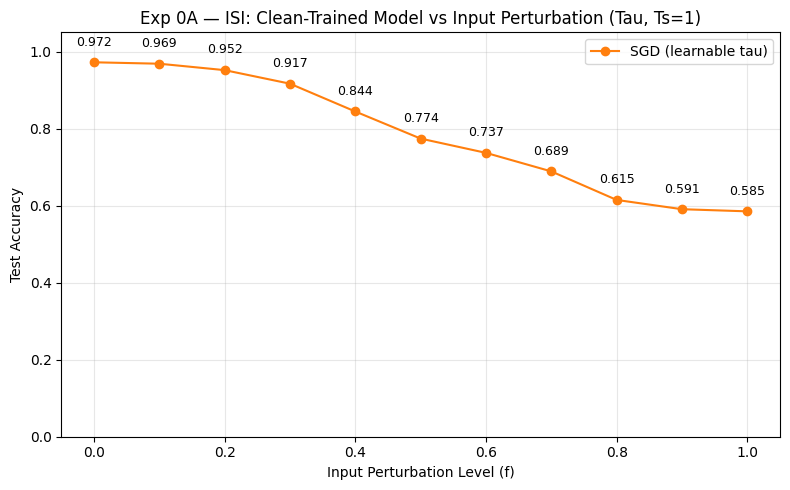

Figure saved to log/isi_tau_input_perturbation.png


In [10]:
def plot_input_perturbation_curve(results: dict) -> None:
    """Plot accuracy vs input perturbation level f."""
    f_vals = sorted(results.keys())
    accs = [results[f] for f in f_vals]

    plt.figure(figsize=(8, 5))
    plt.plot(f_vals, accs, "o-", color="tab:orange", label="SGD (learnable tau)")
    plt.xlabel("Input Perturbation Level (f)")
    plt.ylabel("Test Accuracy")
    plt.title("Exp 0A — ISI: Clean-Trained Model vs Input Perturbation (Tau, Ts=1)")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, acc in zip(f_vals, accs):
        plt.annotate(
            f"{acc:.3f}",
            (f_val, acc),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig("log/isi_tau_input_perturbation.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved to log/isi_tau_input_perturbation.png")


plot_input_perturbation_curve(sweep_results)

## 11. Save Results

In [11]:
results_serialisable = {str(f_val): float(acc) for f_val, acc in sweep_results.items()}
results_path = "log/isi_tau_input_perturbation_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Results saved to {results_path}")

log_serialisable = {
    k: [float(v) for v in vals] if isinstance(vals, list) else vals
    for k, vals in training_log.items()
}
log_path = "log/isi_tau_training_log.json"
with open(log_path, "w") as fp:
    json.dump(log_serialisable, fp, indent=2)
print(f"Training log saved to {log_path}")

Results saved to log/isi_tau_input_perturbation_results.json
Training log saved to log/isi_tau_training_log.json
